# 1.Load data & inspect

In [39]:
import pandas as pd
import numpy as np

df = pd.read_excel("/content/drive/MyDrive/Dataset for Data Analytics.xlsx")
print(df.shape)
print(df.info())
df.head()

(1200, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


# 2. find missing value

In [40]:
missing = df.isnull().sum()
missing_pct = (df.isnull().mean()*100).round(2)
print(pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct}))

                 Missing Count  Missing %
OrderID                      0       0.00
Date                         0       0.00
CustomerID                   0       0.00
Product                      0       0.00
Quantity                     0       0.00
UnitPrice                    0       0.00
ShippingAddress              0       0.00
PaymentMethod                0       0.00
OrderStatus                  0       0.00
TrackingNumber               0       0.00
ItemsInCart                  0       0.00
CouponCode                 309      25.75
ReferralSource               0       0.00
TotalPrice                   0       0.00


# 3. Fix missing value

In [41]:
df['CouponCode'] = df['CouponCode'].fillna('NoCoupon')

# 4. IQR method

In [42]:
def check_outliers(col):
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    low, high = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    return df[(df[col] < low) | (df[col] > high)]

for col in ['Quantity','UnitPrice','ItemsInCart','TotalPrice']:
    print(col, "-> Outliers:", len(check_outliers(col)))

Quantity -> Outliers: 0
UnitPrice -> Outliers: 0
ItemsInCart -> Outliers: 0
TotalPrice -> Outliers: 8


## 5. Clipping the extreme value of Total price

In [43]:
Q1, Q3 = df['TotalPrice'].quantile(0.25), df['TotalPrice'].quantile(0.75)
IQR = Q3 - Q1
low, high = Q1 - 1.5*IQR, Q3 + 1.5*IQR
df['TotalPrice'] = df['TotalPrice'].clip(low, high)

# 6. Create 3 new features

In [44]:
#Discount usage flag
df['UsedCoupon'] = df['CouponCode'].apply(lambda x: 0 if x == 'NoCoupon' else 1)

#Order month (for time trend analysis)
df['Date'] = pd.to_datetime(df['Date'])
df['OrderMonth'] = df['Date'].dt.month

#Average price per item in the order
df['AvgItemValue'] = df['TotalPrice'] / df['Quantity']

# 7. One-Hot Encoding

In [45]:
df_encoded = pd.get_dummies(df, columns=['Product','PaymentMethod','OrderStatus','ReferralSource'], drop_first=True)

# 8. correlation check

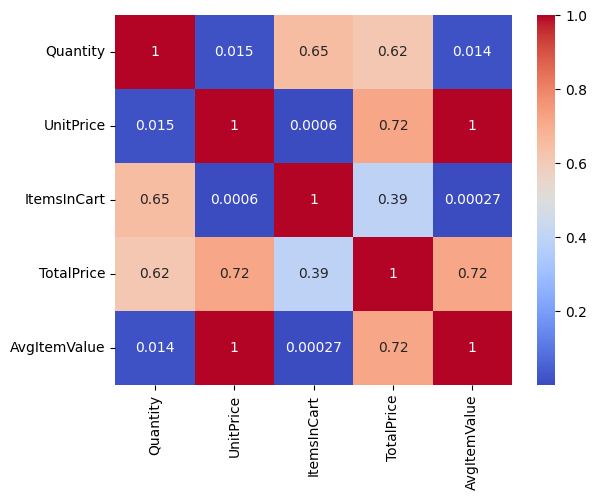

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_before = df[['Quantity','UnitPrice','ItemsInCart','TotalPrice','AvgItemValue']].corr()
sns.heatmap(corr_before, annot=True, cmap='coolwarm')
plt.show()

# 9. Eradicate Collinear Features (> 0.80)

In [47]:
target_col = 'TotalPrice'
feature_cols = ['Quantity', 'UnitPrice', 'ItemsInCart', 'AvgItemValue']
abs_corr = df_encoded[feature_cols].corr().abs()

threshold = 0.80
to_drop = set()

for i in range(len(abs_corr.columns)):
    for j in range(i):
        col1 = abs_corr.columns[i]
        col2 = abs_corr.columns[j]

        if abs_corr.loc[col1, col2] > threshold:
            corr1_target = abs(df_encoded[col1].corr(df_encoded[target_col]))
            corr2_target = abs(df_encoded[col2].corr(df_encoded[target_col]))

            if corr1_target < corr2_target:
                to_drop.add(col1)
            else:
                to_drop.add(col2)

to_drop.discard(target_col)

df_cleaned = df_encoded.drop(columns=list(to_drop))
print(f"Dropped collinear column(s): {list(to_drop)}")

Dropped collinear column(s): ['AvgItemValue']


# 10. Compare Heatmaps (before vs. after)

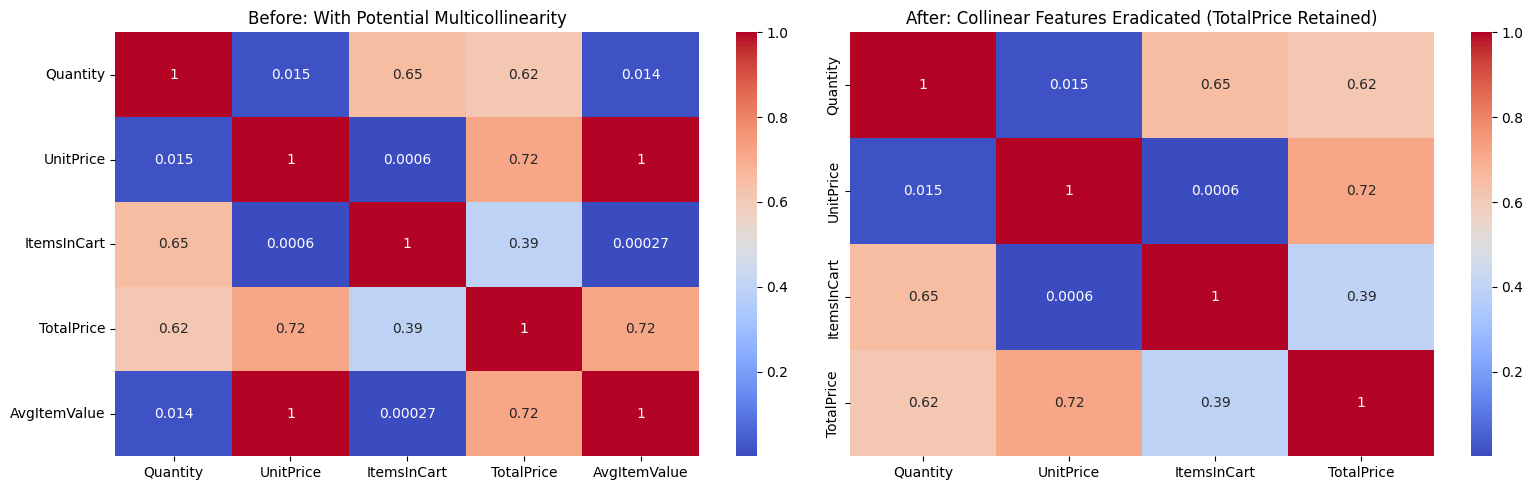

In [48]:
all_num_cols = ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice', 'AvgItemValue']
remaining_num_cols = [col for col in all_num_cols if col in df_cleaned.columns]

corr_before = df_encoded[all_num_cols].corr()
corr_after = df_cleaned[remaining_num_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(corr_before, annot=True, cmap='coolwarm', ax=axes[0])
axes[0].set_title("Before: With Potential Multicollinearity")

sns.heatmap(corr_after, annot=True, cmap='coolwarm', ax=axes[1])
axes[1].set_title("After: Collinear Features Eradicated (TotalPrice Retained)")

plt.tight_layout()
plt.show()

# 9. save the clean dataset

In [49]:
df_cleaned.to_csv("Cleaned_Dataset_Project1.csv", index=False)